In [2]:
!pip install torch

In [3]:
import os
import sys
import torch
import torchvision
from torchvision import transforms
import PIL
from PIL import Image
import zipfile
import pandas as pd
import matplotlib.pyplot as plt

In [6]:
print("Platform:", sys.platform)
print("Python version:", sys.version)
print("---")
print("pandas version:", pd.__version__)
print("PIL version:", PIL.__version__)
print("torch version:", torch.__version__)
print("torchvision version:", torchvision.__version__)

Platform: linux
Python version: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
---
pandas version: 2.2.2
PIL version: 11.3.0
torch version: 2.11.0+cpu
torchvision version: 0.26.0+cpu


In [7]:
zip_path = "/content/drive/MyDrive/sea_creatures.zip"

extraction_path = "/content/datasets"

os.makedirs(extraction_path, exist_ok=True)

# Extract the contents
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extraction_path)
    print("Dataset extracted successfully!")

Dataset extracted successfully!


In [9]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(device)

cpu


# Explore Dataset


In [10]:
data_dir = os.path.join("datasets", "train")

classes = os.listdir(data_dir)

In [15]:
print(classes)
print("=" * 50)
print(f" The number of classification is:{len(classes)}")

['Sea Urchins', 'Puffers', 'Turtle_Tortoise', 'Dolphin', 'Octopus', 'Jelly Fish', 'Whale', 'Sharks', 'Sea Rays']
 The number of classification is:9


In [16]:
class_distribution_dict = {}

for sub_dir in classes:
    class_dir = os.path.join(data_dir, sub_dir)
    num_images = len(os.listdir(class_dir))
    class_distribution_dict[sub_dir] = num_images

class_distributions = pd.Series(class_distribution_dict)
print(class_distributions)

Sea Urchins         524
Puffers             488
Turtle_Tortoise    1716
Dolphin             711
Octopus             495
Jelly Fish          752
Whale               512
Sharks              533
Sea Rays            451
dtype: int64


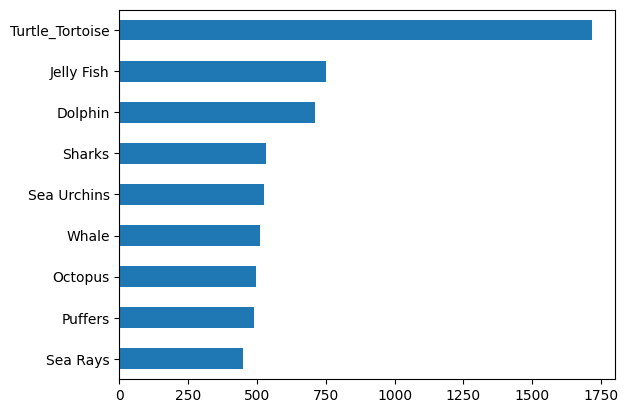

In [17]:
class_distributions.sort_values().plot(kind="barh")
plt.show()

# Image Exploration

In [19]:
dolphin_image_path = os.path.join(os.path.join("datasets", "train") , "Dolphin")
dolphin_images = os.listdir(dolphin_image_path)
print(dolphin_images)

['6011510671_351a6ba29a_o.jpg', 'Dolphin (57).jpg', '5230441013_51ec7741e6_o.jpg', '6054743178_f19e68cc94_o.jpg', '6304502644_0e930be5bc_b.jpg', '353410613_fb1177b61b_o.jpg', '9302877977_9afcc57133_b.jpg', '7926354668_f174ba4344_b.jpg', '29296746446_bb1c47f9b1_o.jpg', 'Dolphin (104).jpg', '8258115570_32afae0746_o.jpg', '4782102875_0d9dc6746a_o.jpg', 'Dolphin (240).jpg', '3809763490_be1d960354_o.jpg', '8429581077_d39c1dc1e2_o.jpg', 'Dolphin (257).jpg', '8185460660_c3b7c01e29_o.jpg', 'Dolphin (110).jpg', 'Dolphin (47).jpg', '16554771605_19e38ac0f1_o.jpg', 'Dolphin (48).jpg', '13015254584_73b1b3f2de_b.jpg', 'Dolphin (186).jpg', '8516536563_3085c43a71_o.jpg', 'Dolphin (36).jpg', '4750842093_68e2099a14_o.jpg', '6895250253_4b27c56164_o.jpg', 'Dolphin (127).jpg', 'Dolphin (194).jpg', '5231035910_7482676c9c_o.jpg', 'Dolphin (267).jpg', '6091413688_112dace94f_b.jpg', 'Dolphin (254).jpg', '3050231370_cecf36b5ca_b.jpg', 'Dolphin (241).jpg', '9792651134_fd81ea9f4b_o.jpg', 'Dolphin (235).jpg', 'Dol

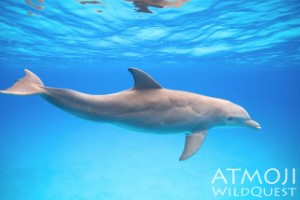

In [22]:
dolphin_image_example = os.path.join(dolphin_image_path, dolphin_images[0])

dolphin_image_pil = Image.open(dolphin_image_example)

dolphin_image_pil

In [24]:
octopus_image_path = os.path.join(os.path.join("datasets", "train") , "Octopus")
octopus_images = os.listdir(octopus_image_path)
print(octopus_images)

['7182822598_23bfa60f42_b.jpg', '33788497533_3f0f652e82_o.jpg', '3670344313_89e3e63cd0_b.jpg', '6805504090_ce318323be_o.jpg', '8445124143_a675ed1039_o.jpg', 'Octopus (7).jpg', '12312162174_fd55976dd5_o.jpg', '16241434840_a2ff30b279_o.jpg', 'Octopus (24).jpg', 'Octopus (42).jpg', '8085444707_9072bfdb0e_o.jpg', '8126660664_8a40c1cf22_o.jpg', '15523214066_1663be08f2_o.jpg', '267060138_a6a84b2e80_o.jpg', '6934707208_9450391359_b.jpg', '7478007190_63d3945cc4_o.jpg', '6482018481_72abc5a1d1_o.jpg', '32958702062_271a2a6249_o.jpg', '5871574669_e096ac122e_b.jpg', '27840430019_f7612ce97d_b.jpg', '236801570_c9c0de8a6f_o.jpg', '44854162135_8a1f1ca138_b.jpg', '30971228880_ab3ffa532f_b.jpg', '16186102197_f039db53f7_o.jpg', 'Octopus (37).jpg', '25065582682_c430f06d86_o.jpg', 'Octopus (16).jpg', '6141862408_b4a354fbbc_o.jpg', 'Octopus (35).jpg', '56427675_1b06ef4618_o.jpg', '9403751164_642b7eef6b_o.jpg', '29082763776_cc645ecf20_o.jpg', '3979663034_936b7b4f98_o.jpg', '30718235961_729da96e5c_o.jpg', '291

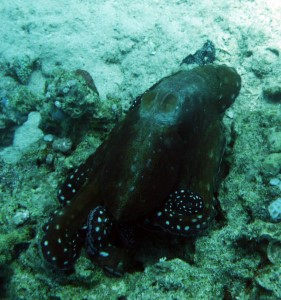

In [26]:
octopus_image_example = os.path.join(octopus_image_path, octopus_images[0])

octopus_image_pil = Image.open(dolphin_image_example)

octopus_image_pil

In [27]:
shark_image_path = os.path.join(os.path.join("datasets", "train") , "Sharks")
shark_images = os.listdir(shark_image_path)
print(shark_images)

['Sharks (57).jpg', 'Sharks (76).jpg', '16493519540_3012b2ddd1_b.jpg', '16451360515_6241fb32c0_o.jpg', '7734193734_70a753b68b_o.jpg', '2275469874_6b7a0b23b4_o.jpg', '4650820269_06eeb7478a_o.jpg', '3134364881_931944b0f5_o.jpg', '33112264532_a033291dbc_b.jpg', '27542018517_f214ce092a_b.jpg', '26466110352_4da59d656d_o.png', '29853334788_14998461c9_o.jpg', '29303339283_a64d41ee54_b.jpg', '4317231913_fea0934616_o.jpg', '16833976965_7a536ea594_o.jpg', '6139294503_6009fafc71_o.jpg', '5255240114_9b6b6f9004_o.jpg', '40118442371_ce802c4f5e_b.jpg', '36462291122_4a04afbcdc_b.jpg', '5959640321_10e50a8523_o.jpg', '6945341402_012aba6d84_b.jpg', 'Sharks (26).jpg', '18867843011_a0b299a600_o.jpg', '44419872161_8e1072630b_o.jpg', '4618317072_6727100bc9_o.jpg', 'Sharks (54).jpg', '288858581_6c078c0f1a_b.jpg', '43865876530_39d195a3a0_b.jpg', 'Sharks (5).jpg', '28483948117_33d2e60835_o.jpg', '24828769580_bbb3a44af0_o.jpg', '10326101766_8a1ffc1769_o.jpg', '7052782157_10aef8d76b_b.jpg', 'Sharks (69).jpg', '85

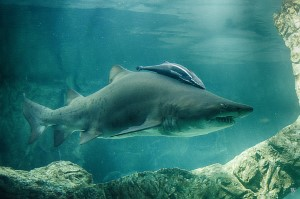

In [28]:
shark_image_xample = os.path.join(shark_image_path, shark_images[2])

shark_image_pil = Image.open(shark_image_xample)

shark_image_pil

# Image Properties


In [32]:
print("Dolphin Image Size:", dolphin_image_pil.size)
print("Shark Image Size:", shark_image_pil.size)
print("Octopus Image Size:", octopus_image_pil.size)

Dolphin Image Size: (300, 200)
Shark Image Size: (300, 199)
Octopus Image Size: (281, 300)


# Insights

The Images are of different sizes which means we will have to resize before coversion into tensors

In [34]:
print("Dolphin Image Mode:", dolphin_image_pil.mode)
print("Shark Image Mode:", shark_image_pil.mode)
print("Octopus Image Mode:", octopus_image_pil.mode)

Dolphin Image Mode: RGB
Shark Image Mode: RGB
Octopus Image Mode: RGB


# Conversion Into Tensors


In [35]:
shark_tensor = transforms.ToTensor()(shark_image_pil)
dolphin_tensor = transforms.ToTensor()(dolphin_image_pil)
octopus_tensor = transforms.ToTensor()(octopus_image_pil)

In [36]:
print("shark tensor type", type(shark_tensor))
print("shark tensor dtype", shark_tensor.dtype)
print("shark tensor shape", shark_tensor.shape)

shark tensor type <class 'torch.Tensor'>
shark tensor dtype torch.float32
shark tensor shape torch.Size([3, 199, 300])


# Explain Tensor Dimension

In [38]:
# Check tensor dimensions
channels, height, width = dolphin_tensor.shape
print(f"Channels: {channels}")
print(f"Height: {height}")
print(f"Width: {width}")

Channels: 3
Height: 200
Width: 300


This shape—(3, 200, 300)—is the standard data format for a single RGB color image ready to be processed by a PyTorch convolutional neural network.

The total number of individual numerical values (pixel intensities) in this tensor is $3 \times 200 \times 300 = \mathbf{180,000}$.

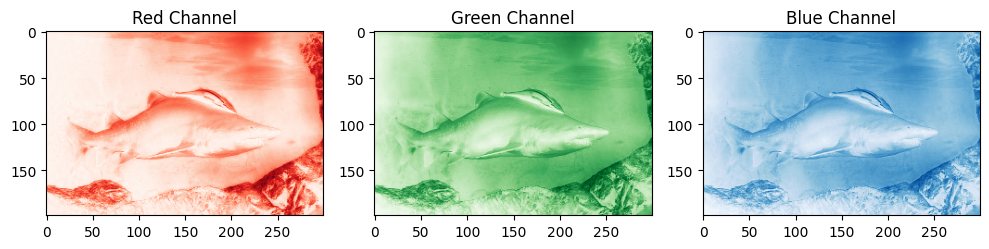

In [39]:
fig, (ax0, ax1, ax2) = plt.subplots(1, 3, figsize=(10, 5))

# Red Channel of shark tensor
ax0.imshow(shark_tensor[0], cmap='Reds')
ax0.set_title('Red Channel')

# Green Channel of shark tensor
ax1.imshow(shark_tensor[1], cmap='Greens')
ax1.set_title('Green Channel')

# Blue Channel of shark tensor
ax2.imshow(shark_tensor[2], cmap='Blues')
ax2.set_title('Blue Channel')

plt.tight_layout()
plt.show()




In [42]:
max_channel_values = shark_tensor.amax(dim=(0, 1, 2))

print(max_channel_values)

tensor(1.)


In [43]:
min_channel_values = shark_tensor.amin(dim=(0, 1, 2))

print(min_channel_values)

tensor(0.)


In [44]:
mean_val = torch.mean(shark_tensor)

std_val = torch.std(shark_tensor)

print(f"Mean: {mean_val.item()}")
print(f"Std: {std_val.item()}")

Mean: 0.381298691034317
Std: 0.20160967111587524
